# Assignment 10: Comparing GAN and VAE Using My Experimental Results

**Objective:** To compare the GAN from Assignment 4 and the VAE from Assignment 8 using the images and training results produced in my own experiments, rather than only comparing their theory.

## Step 1: Importing Libraries

In [1]:
import json
import base64
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## Step 2: Reading the Saved Outputs from Assignments 4 and 8

The trained models themselves were not saved, so this notebook works with the figures already stored in the two assignment notebooks. The helper function below searches for a particular plotting statement and retrieves the image saved by that code cell.

In [9]:
# =========================
# COMPARISON - GAN vs VAE
# =========================

import json
import base64
import io
from PIL import Image
from google.colab import files

# Upload the two source notebooks
print("Upload your Assignment 4 GAN notebook and Assignment 8 VAE notebook.")

uploaded = files.upload()

# Automatically find the uploaded .ipynb files
ipynb_files = list(uploaded.keys())

if len(ipynb_files) < 2:
    raise Exception(
        "Please upload BOTH Assignment 4 (GAN) and Assignment 8 (VAE) notebooks."
    )

# Identify files by checking their contents
GAN_FILE = None
VAE_FILE = None

for filename in ipynb_files:

    with open(filename, encoding="utf-8") as f:
        nb = json.load(f)

    notebook_text = json.dumps(nb)

    if "Fashion-MNIST Images Generated After Training" in notebook_text:
        GAN_FILE = filename

    if "Digits Generated Across the Latent Space" in notebook_text:
        VAE_FILE = filename

if GAN_FILE is None:
    raise Exception("Could not identify the Assignment 4 GAN notebook.")

if VAE_FILE is None:
    raise Exception("Could not identify the Assignment 8 VAE notebook.")


def get_saved_figure(notebook_file, text_in_cell, which=0):

    with open(notebook_file, encoding="utf-8") as f:
        nb = json.load(f)

    for cell in nb["cells"]:

        if cell["cell_type"] != "code":
            continue

        code = "".join(cell.get("source", []))

        if text_in_cell in code:

            pictures = [
                o["data"]["image/png"]
                for o in cell.get("outputs", [])
                if "data" in o and "image/png" in o["data"]
            ]

            if len(pictures) <= which:
                raise ValueError(
                    "Image output not found for: " + text_in_cell
                )

            png_text = pictures[which]

            if isinstance(png_text, list):
                png_text = "".join(png_text)

            return Image.open(
                io.BytesIO(
                    base64.b64decode(png_text)
                )
            ).convert("RGB")

    raise ValueError(
        "No code cell contains: " + text_in_cell
    )


# Get final generated figures
gan_figure = get_saved_figure(
    GAN_FILE,
    "Fashion-MNIST Images Generated After Training"
)

vae_figure = get_saved_figure(
    VAE_FILE,
    "Digits Generated Across the Latent Space"
)

print("GAN file:", GAN_FILE)
print("VAE file:", VAE_FILE)
print("GAN figure size:", gan_figure.size)
print("VAE figure size:", vae_figure.size)

Upload your Assignment 4 GAN notebook and Assignment 8 VAE notebook.


Saving gen_ai_8.ipynb to gen_ai_8 (2).ipynb
Saving GEN_AI-4.ipynb to GEN_AI-4 (2).ipynb
GAN file: GEN_AI-4 (2).ipynb
VAE file: gen_ai_8 (2).ipynb
GAN figure size: (581, 592)
VAE figure size: (980, 989)


## Step 3: Selecting 8 GAN-Generated Images

The GAN output is a 4 × 4 collection of generated Fashion-MNIST images. I selected the first eight images, meaning the first two rows. This fixed selection avoids choosing samples only because they look better.

In [10]:
def find_runs(is_filled, min_length=50):
    runs = []
    start = None

    for i, value in enumerate(is_filled):
        if value and start is None:
            start = i

        if (not value) and start is not None:
            if i - start >= min_length:
                runs.append((start, i))
            start = None

    if start is not None and len(is_filled) - start >= min_length:
        runs.append((start, len(is_filled)))

    return runs


def find_grid(img):
    pixels = np.array(img)
    not_white = pixels.sum(axis=2) < 740

    rows = find_runs(not_white.mean(axis=1) > 0.5)
    cols = find_runs(not_white.mean(axis=0) > 0.5)

    return rows, cols

Row positions   : [(45, 168), (183, 306), (321, 444), (459, 582)]
Column positions: [(10, 133), (156, 279), (302, 425), (448, 571)]
Number of images cut out: 16


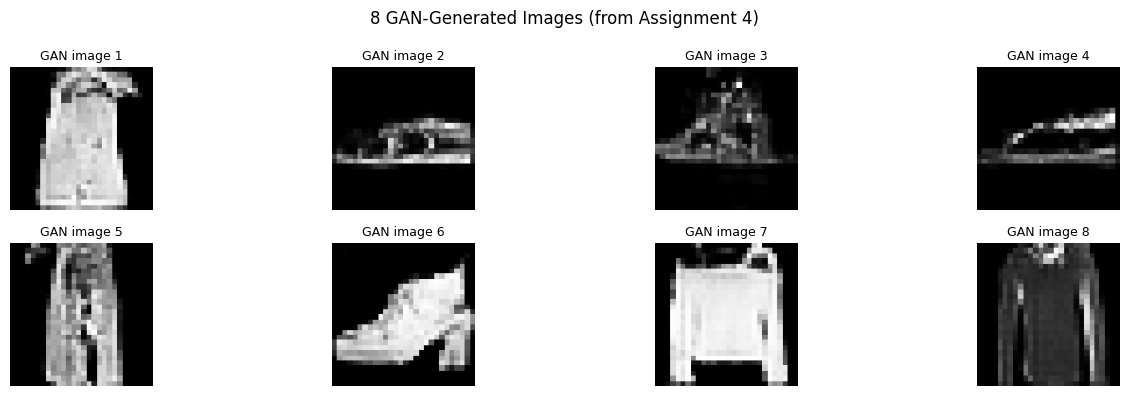

In [11]:
rows, cols = find_grid(gan_figure)

print("Row positions   :", rows)
print("Column positions:", cols)

gan_tiles = [
    gan_figure.crop((c0, r0, c1, r1))
    for (r0, r1) in rows
    for (c0, c1) in cols
]

print("Number of images cut out:", len(gan_tiles))

gan_8 = gan_tiles[:8]

plt.figure(figsize=(14, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(gan_8[i])
    plt.title(f'GAN image {i + 1}', fontsize=9)
    plt.axis('off')

plt.suptitle('8 GAN-Generated Images (from Assignment 4)')
plt.tight_layout()
plt.show()

## Step 4: Selecting 8 VAE-Generated Images

The VAE result is a 15 × 15 grid created by decoding points in its two-dimensional latent space. I selected eight positions at regular intervals: rows 4 and 12, with columns 2, 6, 10 and 14. This keeps the selection systematic instead of choosing only the clearest digits.

In [12]:
rows, cols = find_grid(vae_figure)

print("Row positions   :", rows)
print("Column positions:", cols)

top, bottom = rows[0]
left, right = cols[0]

n = 15
tile_width = (right - left) / n
tile_height = (bottom - top) / n

print(
    f"Size of one image: about "
    f"{tile_width:.1f} x {tile_height:.1f} pixels"
)


def get_vae_tile(r, c):
    return vae_figure.crop((
        round(left + c * tile_width),
        round(top + r * tile_height),
        round(left + (c + 1) * tile_width),
        round(top + (r + 1) * tile_height)
    ))

Row positions   : [(30, 938)]
Column positions: [(65, 972)]
Size of one image: about 60.5 x 60.5 pixels


Number of images selected: 8


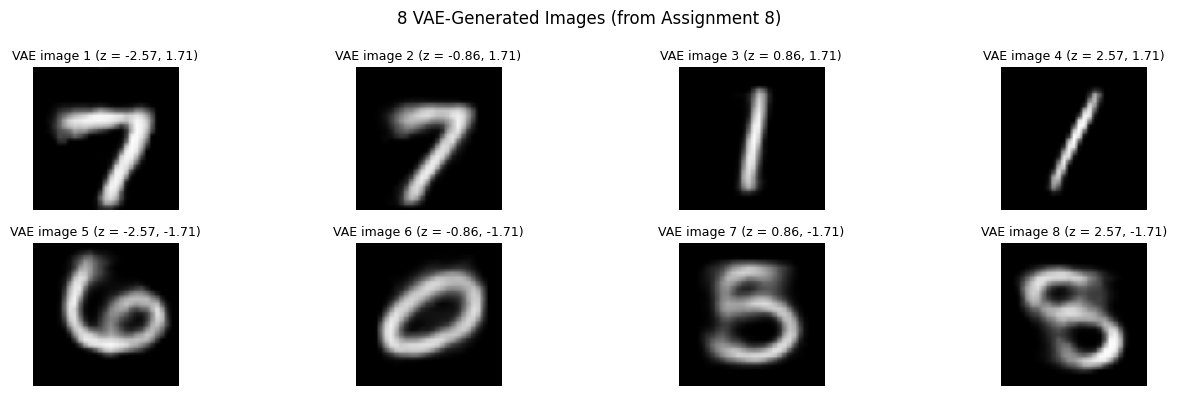

In [13]:
chosen_rows = [3, 11]
chosen_cols = [1, 5, 9, 13]

vae_8 = []
vae_coords = []

for r in chosen_rows:
    for c in chosen_cols:
        vae_8.append(get_vae_tile(r, c))

        x = -3 + c * 6 / (n - 1)
        y = 3 - r * 6 / (n - 1)

        vae_coords.append((x, y))

print("Number of images selected:", len(vae_8))

plt.figure(figsize=(14, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(vae_8[i])
    plt.title(
        f'VAE image {i + 1} '
        f'(z = {vae_coords[i][0]:.2f}, {vae_coords[i][1]:.2f})',
        fontsize=9
    )
    plt.axis('off')

plt.suptitle('8 VAE-Generated Images (from Assignment 8)')
plt.tight_layout()
plt.show()

## Step 5: GAN and VAE Generated Images Side by Side

The following view places the eight selected GAN samples above the eight selected VAE samples. The GAN was trained on Fashion-MNIST clothing, while the VAE was trained on MNIST handwritten digits, so the visual content is different and the comparison is mainly about the behaviour of the two generative approaches.

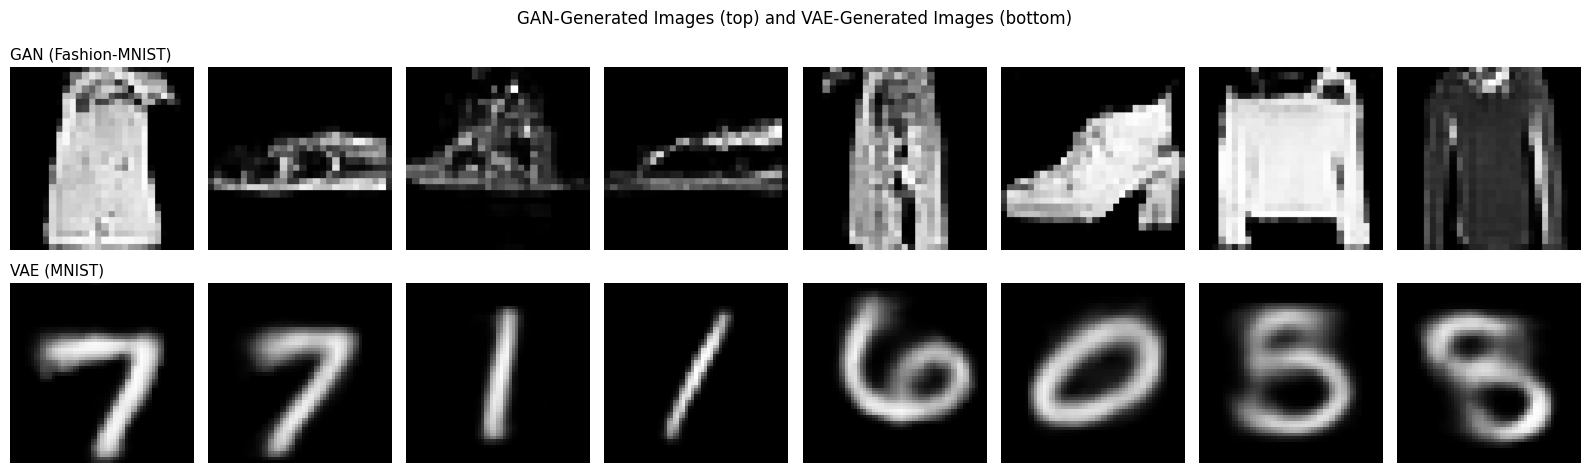

In [14]:
plt.figure(figsize=(16, 5))

for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(gan_8[i])
    plt.axis('off')

    if i == 0:
        plt.title('GAN (Fashion-MNIST)', loc='left', fontsize=11)

    plt.subplot(2, 8, i + 9)
    plt.imshow(vae_8[i])
    plt.axis('off')

    if i == 0:
        plt.title('VAE (MNIST)', loc='left', fontsize=11)

plt.suptitle('GAN-Generated Images (top) and VAE-Generated Images (bottom)')
plt.tight_layout()
plt.show()

## Step 6: Supporting Outputs from Assignments 4 and 8

These results give additional evidence for the comparison:

- Training loss curves are used when discussing stability.
- The VAE reconstruction result helps judge image quality and its usefulness for anomaly detection.
- The VAE outputs at extreme and far-away latent points show what happens outside the main region learned by the model.

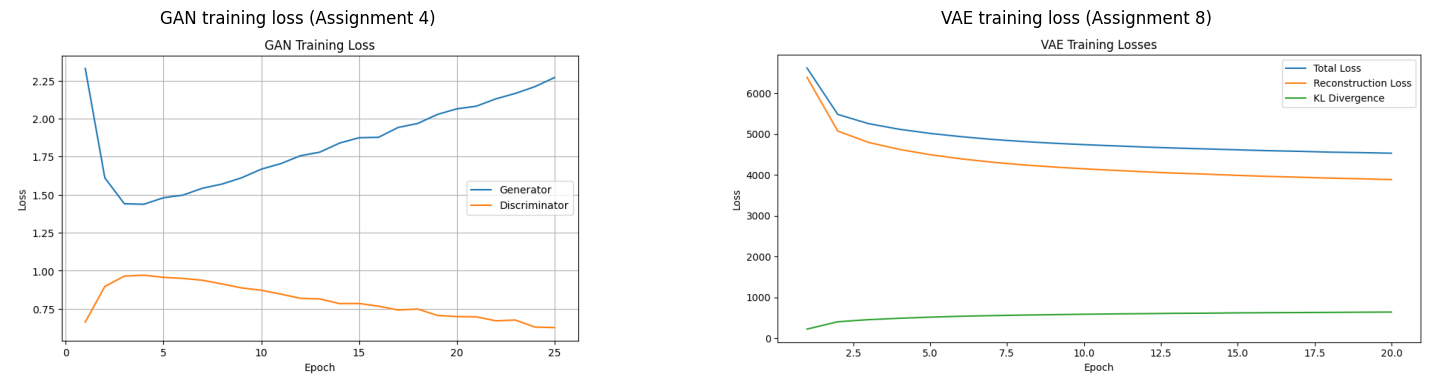

In [15]:
gan_loss_plot = get_saved_figure(
    GAN_FILE, 'GAN Training Loss'
)

vae_loss_plot = get_saved_figure(
    VAE_FILE, 'VAE Training Losses'
)

vae_recon = get_saved_figure(
    VAE_FILE, 'Original Images (Top) and VAE Reconstructions (Bottom)'
)

vae_extreme = get_saved_figure(
    VAE_FILE, 'Decoder Output at Edge Latent Points'
)

vae_outside = get_saved_figure(
    VAE_FILE, 'Decoder Output at Latent Point (10, 10)'
)

plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.imshow(gan_loss_plot)
plt.title('GAN training loss (Assignment 4)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(vae_loss_plot)
plt.title('VAE training loss (Assignment 8)')
plt.axis('off')

plt.tight_layout()
plt.show()

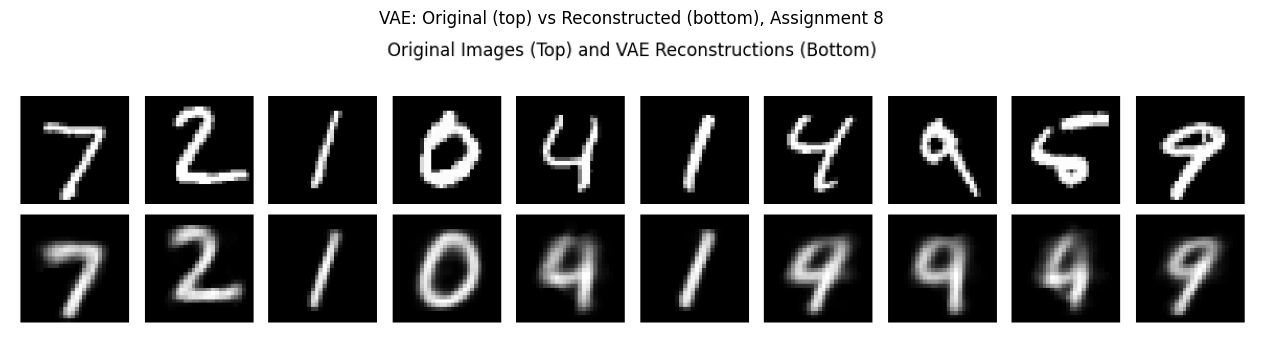

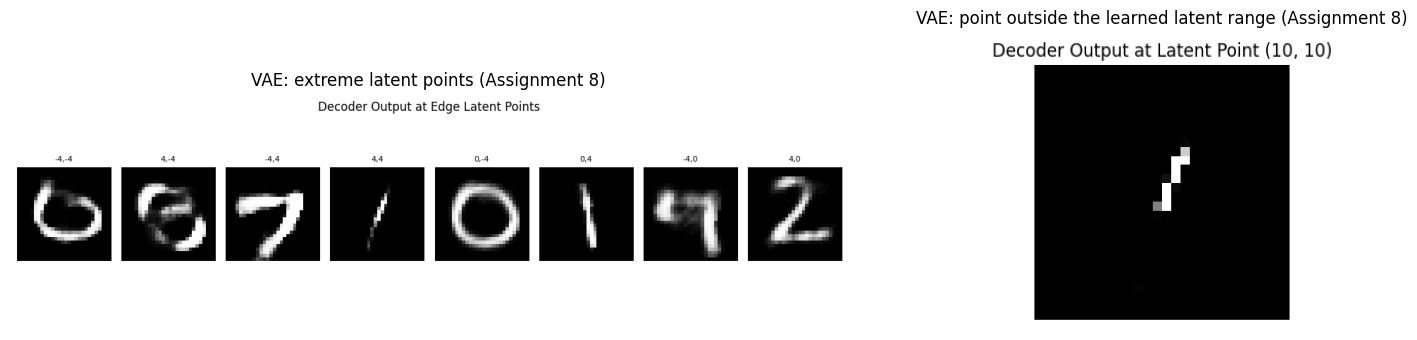

In [16]:
plt.figure(figsize=(14, 3.5))
plt.imshow(vae_recon)
plt.title('VAE: Original (top) vs Reconstructed (bottom), Assignment 8')
plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 3.5))

plt.subplot(1, 2, 1)
plt.imshow(vae_extreme)
plt.title('VAE: extreme latent points (Assignment 8)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(vae_outside)
plt.title('VAE: point outside the learned latent range (Assignment 8)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Step 7: Comparison Table

The table below is based on the eight selected images, the two training-loss plots, and the additional VAE outputs. Since the models were trained on different datasets, the observations describe my particular experiments rather than a controlled benchmark.

| Criteria | GAN (Assignment 4, Fashion-MNIST) | VAE (Assignment 8, MNIST) |
|---|---|---|
| **Image sharpness** | The clearer clothing samples have stronger edges and more defined shapes. Some generated images are still rough or incomplete. | The digits are recognizable, but the strokes and boundaries are noticeably softer and blurrier. |
| **Diversity** | The selected samples contain different clothing forms, including footwear and garments, although some outputs are unclear. | The latent-space sweep covers several digit classes. Nearby latent positions can still produce similar-looking digits. |
| **Realism** | The strongest GAN samples resemble Fashion-MNIST clothing silhouettes fairly well, while weaker samples look like noisy or incomplete objects. | The outputs look like handwritten digits, but the smooth/blurred appearance makes them less realistic than actual MNIST handwriting. |
| **Training stability** | The training was less steady. Generator loss started at 2.3297, reached about 1.44 early on, and increased to 2.2698 by epoch 25, while discriminator loss moved from 0.6630 to 0.6266. | The training trend was smoother. Total loss decreased from 6613.62 to 4529.91 over 20 epochs, while the KL term increased gradually from 227.76 to 644.28. |
| **Ease of controlling the output** | More difficult in this experiment because generation starts from a 100-dimensional random noise vector and there was no direct class selector. | Easier to explore because generation uses a 2D latent space. Choosing a coordinate gives a known location from which the decoder produces an image. |
| **Risk of mode collapse** | There is some risk because GAN training is sensitive to the balance between generator and discriminator. Complete collapse was not observed here because different clothing forms appeared. | The selected latent outputs do not show obvious collapse. However, similar digits can appear repeatedly because the latent space is deliberately compact. |
| **Typical applications** | Realistic image generation, synthetic-data creation, image synthesis and related generative tasks. | Reconstruction, anomaly detection, representation learning, latent-space exploration and controlled generation. |

**Things to keep in mind:** the GAN and VAE were trained on different datasets, each model was trained only once, and only eight images from each were inspected. The VAE also uses a very small 2D latent space, which can contribute to its smooth outputs. These limitations mean the table should be read as a summary of these experiments, not as a universal ranking of GANs and VAEs.

## Final Decision

**1. Which model would I prefer for generating synthetic training data?**

I would prefer the **GAN**. In my selected outputs, the clearer GAN samples have sharper boundaries and more convincing clothing shapes than the VAE samples. If the main requirement is synthetic images that visually resemble the training data, the GAN is the stronger choice from these experiments. I would still filter the generated images before using them because several GAN outputs were not clean.

**2. Which model would I prefer for anomaly detection?**

I would prefer the **VAE**. Its encoder-decoder structure allows an existing image to be encoded and reconstructed. That makes reconstruction error useful as a possible anomaly score: an input that is unlike the training distribution may be reconstructed poorly. The reconstruction output and the degraded results at extreme/far-away latent points in Assignment 8 support this reasoning. I did not perform a separate anomaly-detection accuracy test, so this is a conclusion based on the observed experiment rather than a measured benchmark.

**3. Why?**

The GAN produced sharper and more realistic-looking samples, so it is more attractive for synthetic-data generation. The VAE produced softer images, but it was easier to explore through its 2D latent space and, more importantly, it could reconstruct an input through its encoder and decoder. That reconstruction ability makes the VAE more suitable for anomaly-detection workflows.

**Overall:** for my experiments, I would choose **GAN for generating synthetic training data** and **VAE for anomaly detection**.

**Limitations:** the datasets were different, the experiments were single runs, the VAE had only two latent dimensions, and the comparison used only eight generated images per model.